# Projekt 01 (basic) — Musterloesung: Wegsuche im Labyrinth — von BFS zu A\*

**Ziel:** Du implementierst Breitensuche (BFS) und A\* fuer ein Gitter-Labyrinth und
*siehst* im direkten Vergleich, warum eine gute Heuristik so viel bringt.

**So arbeitest du:** Fuehre die Zellen von oben nach unten aus (`Shift + Enter`).
Zellen mit `# TODO` musst du selbst vervollstaendigen. Wenn du feststeckst:
Hinweise stehen jeweils direkt in der Zelle, die komplette Musterloesung liegt in
`loesung/loesung.ipynb` — erst selbst probieren!

**Bezug zum Skript:** Abschnitt 1.3 (Problemloesen durch Suche) im Modul-README.

## 1. Die Welt: ein Gitter-Labyrinth

Wir stellen das Labyrinth als Liste von Strings dar — gut lesbar und leicht zu aendern:

- `#` = Wand, `.` = freies Feld, `S` = Start, `Z` = Ziel

Ein **Zustand** ist einfach eine Position `(zeile, spalte)`. Die **Aktionen** sind
Schritte nach oben/unten/links/rechts (keine Diagonalen), jede kostet 1.

In [1]:
LABYRINTH = [
    "####################",
    "#S...#........#....#",
    "#.##.#.######.#.##.#",
    "#.#..#......#.#..#.#",
    "#.#.####.##.#.##.#.#",
    "#.#....#.#..#....#.#",
    "#.####.#.#.#######.#",
    "#......#.#.......#.#",
    "######.#.#######.#.#",
    "#....#.#.......#.#.#",
    "#.##.#.#######.#.#.#",
    "#.#..#.......#.#.#.#",
    "#.#.########.#.#.#.#",
    "#.#...............Z#",
    "####################",
]

def parse_labyrinth(zeilen):
    """Liefert (waende, start, ziel): waende ist ein Set von (z, s)-Positionen."""
    waende, start, ziel = set(), None, None
    for z, zeile in enumerate(zeilen):
        for s, feld in enumerate(zeile):
            if feld == "#":
                waende.add((z, s))
            elif feld == "S":
                start = (z, s)
            elif feld == "Z":
                ziel = (z, s)
    return waende, start, ziel

WAENDE, START, ZIEL = parse_labyrinth(LABYRINTH)
HOEHE, BREITE = len(LABYRINTH), len(LABYRINTH[0])
print(f"Labyrinth {HOEHE}x{BREITE}, Start {START}, Ziel {ZIEL}, {len(WAENDE)} Wandfelder")

Labyrinth 15x20, Start (1, 1), Ziel (13, 18), 165 Wandfelder


## 2. Das Uebergangsmodell: Nachbarfelder

Erste Aufgabe: Schreibe die Funktion `nachbarn(pos)`, die alle **begehbaren**
Nachbarfelder einer Position liefert (oben, unten, links, rechts — aber keine
Waende und nichts ausserhalb des Gitters).

In [2]:
def nachbarn(pos):
    """Alle begehbaren Nachbarpositionen von pos = (zeile, spalte)."""
    z, s = pos
    ergebnis = []
    for dz, ds in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nz, ns = z + dz, s + ds
        if 0 <= nz < HOEHE and 0 <= ns < BREITE and (nz, ns) not in WAENDE:
            ergebnis.append((nz, ns))
    return ergebnis

# Mini-Test — muss beides True ausgeben:
print(sorted(nachbarn(START)) == [(1, 2), (2, 1)])   # Start: frei nach rechts und unten
print((13, 17) in nachbarn(ZIEL))                    # links vom Ziel ist frei

True
True


## 3. Breitensuche (BFS)

BFS expandiert Knoten in der Reihenfolge ihrer Entdeckung (FIFO-Warteschlange) und
findet so garantiert einen **kuerzesten** Pfad (alle Schritte kosten 1).

Wir merken uns fuer jeden besuchten Knoten seinen **Vorgaenger**, um am Ende den
Pfad rueckwaerts ablaufen zu koennen. Ausserdem zaehlen wir die **expandierten
Knoten** — unsere Vergleichsgroesse fuer spaeter.

In [3]:
from collections import deque

def rekonstruiere_pfad(vorgaenger, ziel):
    """Laeuft die Vorgaenger-Kette vom Ziel zurueck zum Start."""
    pfad, pos = [], ziel
    while pos is not None:
        pfad.append(pos)
        pos = vorgaenger[pos]
    return pfad[::-1]

def bfs(start, ziel):
    """Liefert (pfad, expandierte_knoten)."""
    frontier = deque([start])
    vorgaenger = {start: None}
    expandiert = []
    while frontier:
        pos = frontier.popleft()
        expandiert.append(pos)
        if pos == ziel:
            return rekonstruiere_pfad(vorgaenger, ziel), expandiert
        for n in nachbarn(pos):
            if n not in vorgaenger:
                vorgaenger[n] = pos
                frontier.append(n)
    return None, expandiert  # kein Pfad gefunden

pfad_bfs, exp_bfs = bfs(START, ZIEL)
print(f"BFS: Pfadlaenge {len(pfad_bfs) - 1} Schritte, {len(exp_bfs)} Knoten expandiert")

BFS: Pfadlaenge 29 Schritte, 54 Knoten expandiert


## 4. Sichtbar machen

Eine kleine Zeichenfunktion (fertig vorgegeben — einfach ausfuehren): Waende schwarz,
expandierte Knoten hellblau, der gefundene Pfad rot.

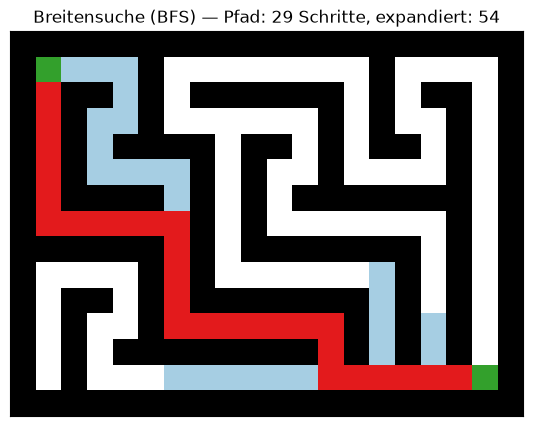

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def zeichne(expandiert, pfad, titel):
    raster = np.zeros((HOEHE, BREITE))          # 0 frei
    for w in WAENDE: raster[w] = 1              # 1 Wand
    for p in expandiert: raster[p] = 2          # 2 expandiert
    for p in pfad: raster[p] = 3                # 3 Pfad
    raster[START], raster[ZIEL] = 4, 4          # 4 Start/Ziel
    farben = ListedColormap(["white", "black", "#a6cee3", "#e31a1c", "#33a02c"])
    plt.figure(figsize=(7, 5))
    plt.imshow(raster, cmap=farben, vmin=0, vmax=4)
    plt.title(f"{titel} — Pfad: {len(pfad)-1} Schritte, expandiert: {len(expandiert)}")
    plt.xticks([]); plt.yticks([])
    plt.show()

zeichne(exp_bfs, pfad_bfs, "Breitensuche (BFS)")

## 5. A\*: Suche mit Richtungssinn

BFS breitet sich blind in alle Richtungen aus. A\* nutzt eine **Heuristik** $h(n)$
(geschaetzte Restkosten zum Ziel) und expandiert immer den Knoten mit kleinstem

$$f(n) = g(n) + h(n)$$

($g$ = bisherige Kosten). Fuer Gitter ohne Diagonalen ist die **Manhattan-Distanz**
die passende zulaessige Heuristik:

$$h((z,s)) = |z - z_{ziel}| + |s - s_{ziel}|$$

Sie ueberschaetzt nie (jeder Schritt verringert die Distanz um hoechstens 1),
also findet A\* garantiert den optimalen Pfad.

Fuer die Prioritaetswarteschlange nutzen wir Pythons `heapq`: ein Heap, aus dem
`heappop` immer das kleinste Element holt. Wir legen Tupel `(f, position)` hinein.

A*:  Pfadlaenge 29 Schritte, 35 Knoten expandiert


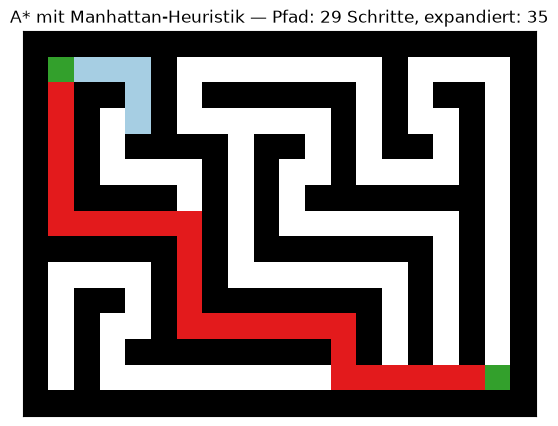

In [5]:
import heapq

def manhattan(pos, ziel):
    return abs(pos[0] - ziel[0]) + abs(pos[1] - ziel[1])

def a_stern(start, ziel, h):
    """A*-Suche. h ist die Heuristikfunktion h(pos, ziel). Liefert (pfad, expandierte)."""
    frontier = [(h(start, ziel), start)]        # Heap mit (f, position)
    vorgaenger = {start: None}
    g = {start: 0}                              # bisherige Kosten pro Knoten
    expandiert = []
    while frontier:
        _, pos = heapq.heappop(frontier)
        if pos in expandiert:                   # veralteter Heap-Eintrag
            continue
        expandiert.append(pos)
        if pos == ziel:
            return rekonstruiere_pfad(vorgaenger, ziel), expandiert
        for n in nachbarn(pos):
            g_neu = g[pos] + 1
            if n not in g or g_neu < g[n]:
                g[n] = g_neu
                vorgaenger[n] = pos
                heapq.heappush(frontier, (g_neu + h(n, ziel), n))
    return None, expandiert

pfad_astar, exp_astar = a_stern(START, ZIEL, manhattan)
print(f"A*:  Pfadlaenge {len(pfad_astar) - 1} Schritte, {len(exp_astar)} Knoten expandiert")
zeichne(exp_astar, pfad_astar, "A* mit Manhattan-Heuristik")

## 6. Der Vergleich

Beide finden einen gleich langen (optimalen) Pfad — aber schau auf die Anzahl
expandierter Knoten! Zum Abschluss noch zwei Experimente:

1. **Greedy Best-First** = A\* ohne $g$: Wir uebergeben eine "Heuristik", zaehlen
   aber $g$ nicht mit. Das simulieren wir, indem wir in `a_stern` einfach eine
   Funktion einsetzen, die die Manhattan-Distanz stark gewichtet — je staerker,
   desto gieriger.
2. **Nullheuristik** $h = 0$: Dann ist $f = g$ und A\* wird zur Uniform-Cost-Suche
   (hier identisch mit BFS-Verhalten).

In [6]:
# Experiment: verschiedene Heuristiken im Vergleich
kandidaten = {
    "h = 0 (Uniform Cost / wie BFS)": lambda p, z: 0,
    "h = Manhattan (A*)":             manhattan,
    "h = 5 * Manhattan (gierig!)":    lambda p, z: 5 * manhattan(p, z),
}
print(f"{'Heuristik':<35}{'Pfadlaenge':>12}{'expandiert':>12}")
for name, h in kandidaten.items():
    pfad, exp = a_stern(START, ZIEL, h)
    print(f"{name:<35}{len(pfad) - 1:>12}{len(exp):>12}")

Heuristik                            Pfadlaenge  expandiert
h = 0 (Uniform Cost / wie BFS)               29          54
h = Manhattan (A*)                           29          35
h = 5 * Manhattan (gierig!)                  31          32


**Beobachtung:** Die gierige Variante (überhoehte Heuristik) expandiert am wenigsten
Knoten — findet aber je nach Labyrinth einen **laengeren** Pfad, weil eine
ueberschaetzende Heuristik die Optimalitaetsgarantie zerstoert (Skript, Abschnitt 1.3).
Manhattan ist der Sweet Spot: optimal *und* deutlich sparsamer als blinde Suche.

## Geschafft — was du jetzt kannst

- ein Problem als Zustandsraum formulieren (Zustaende, Aktionen, Ziel, Kosten)
- BFS und A\* implementieren und den Pfad rekonstruieren
- erklaeren und *zeigen*, was Zulaessigkeit einer Heuristik praktisch bedeutet

**Bonusaufgaben** (optional, ohne Musterloesung):
1. Baue Gewichte ein: `~`-Felder (Sumpf) kosten 5 statt 1. Wo muss der Code sich aendern?
2. Erlaube Diagonalschritte (Kosten $\sqrt{2}$). Warum ist Manhattan dann NICHT mehr zulaessig, und welche Heuristik passt stattdessen?
3. Miss mit `%timeit` die Laufzeit von BFS vs. A\* auf einem groesseren Zufallslabyrinth.